# Bài Tập Về Nhà — Buổi 1: Bản Chất Ảnh Số

**Họ và tên:** _(điền tên)_  
**Ngày nộp:** _(điền ngày)_

---

**Hướng dẫn:**
- Mỗi bài đều có phần `# TODO:` — đó là chỗ bạn cần tự viết code
- Không được dùng code từ buổi học copy vào — tự gõ lại để nhớ
- Chạy từng cell theo thứ tự, đọc kỹ yêu cầu trước khi code
- Nộp file `.ipynb` đã chạy đầy đủ (có output hiển thị)

| Bài | Nội dung | Điểm |
|-----|----------|------|
| 1 | Import thư viện & đọc ảnh | 1 |
| 2 | Khám phá thông tin ảnh | 2 |
| 3 | Truy cập và chỉnh sửa pixel | 2 |
| 4 | Cắt và lật ảnh | 2 |
| 5 | Tách kênh màu | 1 |
| 6 | Tự viết hàm chuyển Grayscale | 2 |
| **Tổng** | | **10** |

---
## Bài 1 — Import thư viện & đọc ảnh (1 điểm)

Không dùng gợi ý, tự nhớ lại tên các thư viện và cách import đúng.

In [1]:
%pip install matplotlib cv2

     ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
     ---------------------------------------- 0.0/8.2 MB 1.4 MB/s eta 0:00:06
     ---------------------------------------- 0.1/8.2 MB 1.1 MB/s eta 0:00:08
      --------------------------------------- 0.2/8.2 MB 1.3 MB/s eta 0:00:07
     - -------------------------------------- 0.3/8.2 MB 1.6 MB/s eta 0:00:05
     -- ------------------------------------- 0.5/8.2 MB 2.4 MB/s eta 0:00:04
     ---- ----------------------------------- 1.0/8.2 MB 3.8 MB/s eta 0:00:02
     --------- ------------------------------ 2.0/8.2 MB 6.5 MB/s eta 0:00:01
     ------------------ --------------------- 3.8/8.2 MB 10.7 MB/s eta 0:00:01
     ----------------------------- ---------- 6.1/8.2 MB 15.1 MB/s eta 0:00:01
     ---------------------------------------- 8.2/8.2 MB 18.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


ERROR: Ignored the following versions that require a different python version: 3.11.0 Requires-Python >=3.11; 3.11.0rc1 Requires-Python >=3.11; 3.11.0rc2 Requires-Python >=3.11
ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)
ERROR: No matching distribution found for cv2

[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# TODO: Import 3 thư viện cần thiết cho khóa học
# Gợi ý: một thư viện xử lý ảnh, một thư viện tính toán ma trận, một thư viện vẽ đồ thị

import numpy as np
import matplotlib.pyplot as plt
import cv2


# TODO: Đọc ảnh từ file vào biến tên `img`
# Dùng ảnh bất kỳ trên máy bạn, đặt vào cùng thư mục với notebook này

img = cv2.imread("anh.jpg")

# TODO: Kiểm tra xem ảnh đọc thành công chưa.
# Nếu đọc thất bại, OpenCV trả về giá trị gì? In ra để kiểm tra.

print(img)
# Nếu đọc thành công, print sẽ trả về ma trận ảnh, nếu không thành công sẽ trả về None

[[[  2   0   0]
  [  3   1   0]
  [  5   3   2]
  ...
  [  0   0   1]
  [  0   0   1]
  [  0   0   1]]

 [[  2   0   0]
  [  2   0   0]
  [  2   0   0]
  ...
  [  0   1   2]
  [  0   1   2]
  [  0   1   2]]

 [[  2   1   3]
  [  1   1   1]
  [  0   0   1]
  ...
  [  1   3   4]
  [  1   3   4]
  [  1   3   4]]

 ...

 [[ 39  55  98]
  [ 37  54  97]
  [ 30  49  92]
  ...
  [ 42  62 110]
  [ 39  59 107]
  [ 28  48  96]]

 [[ 32  49  92]
  [ 28  47  90]
  [ 24  43  86]
  ...
  [ 41  61 109]
  [ 34  54 102]
  [ 19  39  87]]

 [[ 25  44  87]
  [ 24  43  86]
  [ 22  44  86]
  ...
  [ 39  59 107]
  [ 30  50  98]
  [ 11  31  79]]]


---
## Bài 2 — Khám phá thông tin ảnh (2 điểm)

Sau khi đọc được ảnh, nhiệm vụ đầu tiên của một CV engineer là hiểu mình đang làm việc với dữ liệu như thế nào.

In [6]:
# TODO: In ra các thông tin sau của biến `img`:
# 1. Shape (kích thước)
# 2. Dtype (kiểu dữ liệu)
# 3. Chiều cao và chiều rộng (tách riêng từ shape, không được gõ cứng số)
# 4. Số kênh màu
# 5. Tổng số pixel trong ảnh (tính bằng phép nhân, không dùng hàm)

dtype('uint8')

In [12]:
# Kích thước
img.shape

(920, 736, 3)

In [13]:
# Dtype
img.dtype

dtype('uint8')

In [14]:
# Chiều dài
img.shape[0]

920

In [15]:
# Chiều rộng
img.shape[1]

736

In [16]:
# Số kênh màu
img.shape[2]

3

In [17]:
# Tổng số pixel
img.shape[0] * img.shape[1]

677120

Text(0.5, 1.0, 'Con mèo giơ tay như Hitler')

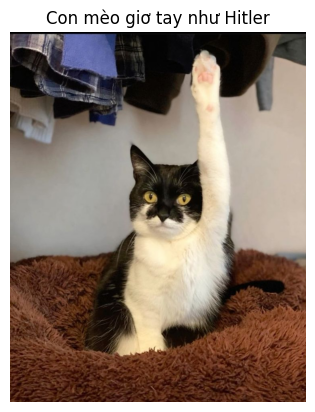

In [53]:
# TODO: Hiển thị ảnh bằng matplotlib
# Lưu ý: OpenCV đọc ảnh theo thứ tự kênh màu BGR, matplotlib hiển thị theo RGB
# Nếu bạn không xử lý điều này, màu sắc sẽ bị sai — hãy tự tìm cách fix

new_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(new_img)
# TODO: Sau khi hiển thị đúng, thêm tiêu đề cho ảnh và tắt trục tọa độ
plt.axis("off")
plt.title("Con mèo giơ tay như Hitler")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [90.263855..122.06566].


105.12898649180845
90.26385278827978
103.05744476606806
122.0656619210775


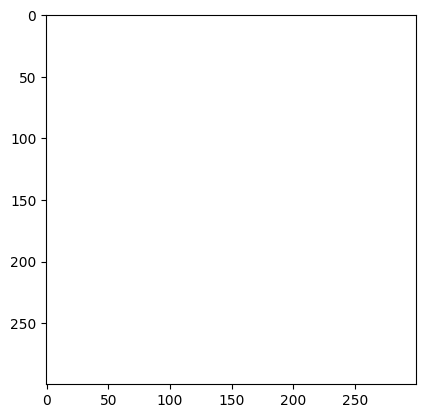

In [32]:
# TODO: Tính giá trị trung bình (mean) của TOÀN BỘ ảnh
# Sau đó tính mean riêng cho từng kênh B, G, R
# In kết quả rõ ràng, làm tròn 2 chữ số thập phân

mean_all = cv2.mean(img)[:3]
mean_b = mean_all[0]
mean_g = mean_all[1]
mean_r = mean_all[2]

img_arr = np.array(img)
mean = np.mean(img_arr)
print(mean, mean_b, mean_g, mean_r, sep="\n")

# Câu hỏi: Nhìn vào 3 giá trị mean của 3 kênh, bạn đoán ảnh này có màu chủ đạo là gì?
# Trả lời: Màu trắng

mean_img = np.zeros((300, 300, 3), dtype = np.float32)
mean_img[:, :] = [mean_b, mean_g, mean_r]
plt.imshow(mean_img)

---
## Bài 3 — Truy cập và chỉnh sửa pixel (2 điểm)

Ảnh là một ma trận số — bạn có thể đọc và ghi từng giá trị như với NumPy array bình thường.

In [41]:
# TODO: Đọc giá trị pixel tại vị trí hàng 100, cột 200
# In ra giá trị của từng kênh riêng biệt (B, G, R)

pb = img[100, 200, 0]
pg = img[100, 200, 1]
pr = img[100, 200, 2]
print(pb, pg, pr, sep="\n")
# TODO: Đọc giá trị pixel ở ĐÚNG TRUNG TÂM của ảnh
# Không được gõ cứng tọa độ — phải tính từ shape

h = img.shape[0]
w = img.shape[1]

pc = img[h // 2, w // 2]
print(pc, sep="\n")
# TODO: So sánh: pixel ở góc trên trái và pixel ở góc dưới phải có khác nhau không?
# In ra cả hai để so sánh
top_left = img[0,0]
bottom_right = img[h - 1, w - 1]

print(top_left, "and", bottom_right)


65
47
46
[113 142 157]
[2 0 0] and [11 31 79]


In [47]:
# TODO: Vẽ một hình chữ nhật màu trắng lên ảnh bằng cách gán giá trị pixel trực tiếp
# Vùng cần tô trắng: từ hàng 50 đến 150, từ cột 50 đến 250
# KHÔNG dùng cv2.rectangle — chỉ dùng array slicing và gán giá trị
# Gợi ý: màu trắng trong ảnh RGB có giá trị pixel là bao nhiêu?

img_copy = img.copy()   # làm việc trên bản sao để không hỏng ảnh gốc

img_copy[50:150, 50:250] = (255,255,255)


# TODO: Hiển thị ảnh trước và sau khi vẽ cạnh nhau để thấy sự khác biệt

(np.float64(-0.5), np.float64(735.5), np.float64(919.5), np.float64(-0.5))

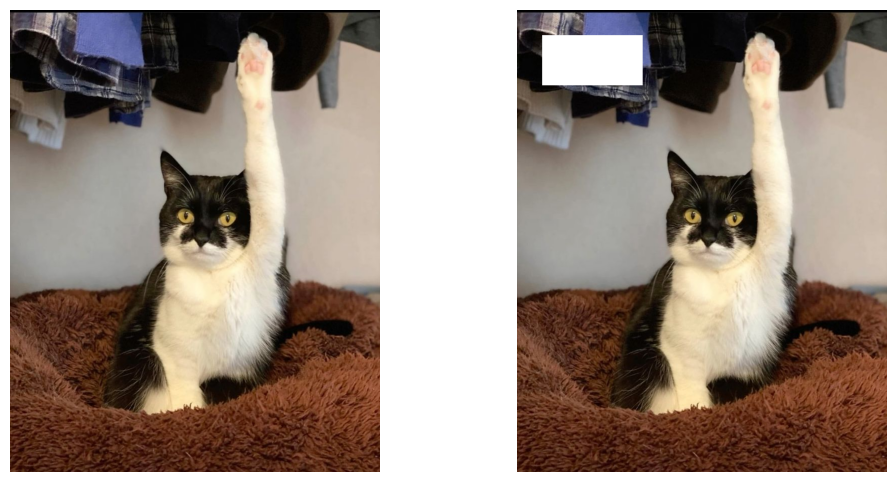

In [55]:
fig, axes = plt.subplots(1,2,figsize=(12,6))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
axes[1].axis("off")

---
## Bài 4 — Cắt và lật ảnh (2 điểm)

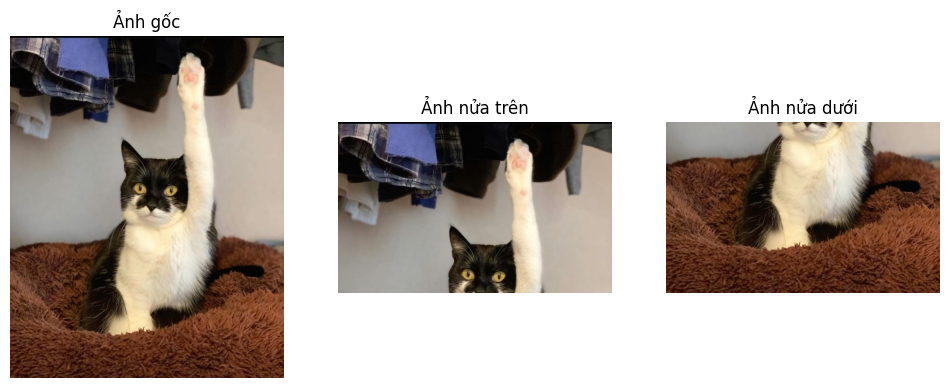

In [54]:
# TODO: Cắt phần NỬA TRÊN của ảnh và lưu vào biến `nua_tren`
# Cắt phần NỬA DƯỚI vào biến `nua_duoi`
# Không được gõ cứng số — phải tính từ shape

nua_tren = img[:h//2,:]
nua_duoi = img[h//2:, :]
# TODO: Hiển thị cả 3 (ảnh gốc, nửa trên, nửa dưới) trên cùng một figure
# Đặt tiêu đề cho từng ảnh

fig, axes = plt.subplots(1, 3, figsize=(12,6))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].axis("off")
axes[0].set_title("Ảnh gốc")

axes[1].imshow(cv2.cvtColor(nua_tren, cv2.COLOR_BGR2RGB))
axes[1].axis("off")
axes[1].set_title("Ảnh nửa trên")

axes[2].imshow(cv2.cvtColor(nua_duoi, cv2.COLOR_BGR2RGB))
axes[2].axis("off")
axes[2].set_title("Ảnh nửa dưới")
plt.show()

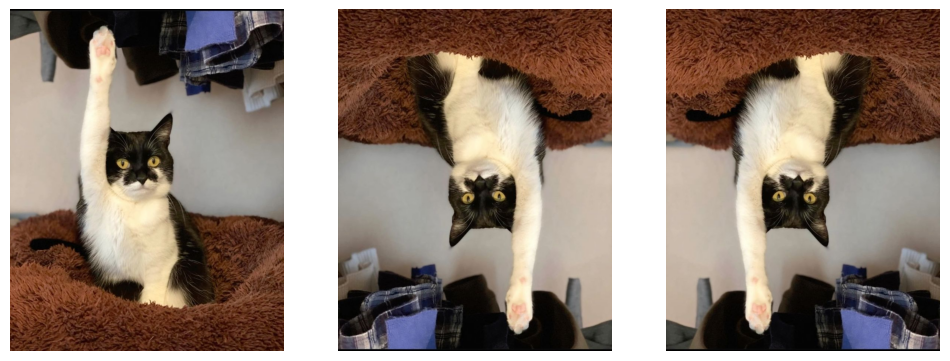

In [59]:
# TODO: Lật ảnh gốc theo 3 cách và hiển thị cạnh nhau:
# - Lật ngang (mirror)
# - Lật dọc (upside down)  
# - Lật cả hai chiều
# Chỉ dùng NumPy slicing, không dùng cv2.flip

mirror = img[:, ::-1]
upside_down = img[::-1, :]
two_side = img[::-1, ::-1]

fig, axes = plt.subplots(1, 3, figsize=(12,6))

axes[0].imshow(cv2.cvtColor(mirror, cv2.COLOR_BGR2RGB))
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(upside_down, cv2.COLOR_BGR2RGB))
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(two_side, cv2.COLOR_BGR2RGB))
axes[2].axis("off")

plt.show()

(np.float64(-0.5), np.float64(735.5), np.float64(919.5), np.float64(-0.5))

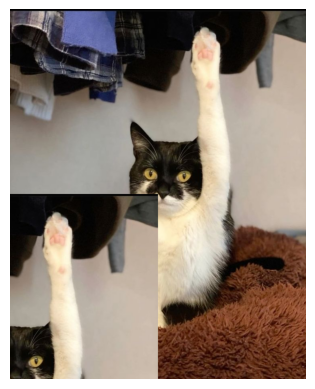

In [63]:
# BÀI TẬP KHÓ HƠN:
# TODO: Cắt góc trên bên phải của ảnh (1/4 diện tích)
# Dán vùng đó vào góc dưới bên trái của ảnh (ghi đè lên)
# Hiển thị kết quả
# Gợi ý: cần copy cẩn thận để không bị reference cùng một vùng nhớ

img_copy2 = img.copy()

sliced = img_copy2[:h//2, w//2:w]

img_copy2[h//2:h, :w//2] = sliced

plt.imshow(cv2.cvtColor(img_copy2, cv2.COLOR_BGR2RGB))
plt.axis("off")

---
## Bài 5 — Tách kênh màu (1 điểm)

In [ ]:
# TODO: Tách ảnh thành 3 kênh B, G, R riêng biệt
# Có ít nhất 2 cách để làm điều này — thử cả hai:
# Cách 1: dùng hàm của OpenCV
# Cách 2: dùng NumPy indexing
print(img.shape)
# Cách 1:
blue, green, red = cv2.split(img)
print(blue.shape, green.shape, red.shape, sep=", ")

# Cách 2:

np_blue = img[:,:,0]
np_green = img[:,:,1]
np_red = img[:,:,2]
print(np_blue.shape, np_green.shape, np_red.shape, sep=", ")

# TODO: Kiểm tra shape của từng kênh sau khi tách — có gì thay đổi so với ảnh gốc không?

# Trả lời: Không khác

(920, 736, 3)
(920, 736), (920, 736), (920, 736)
(920, 736), (920, 736), (920, 736)


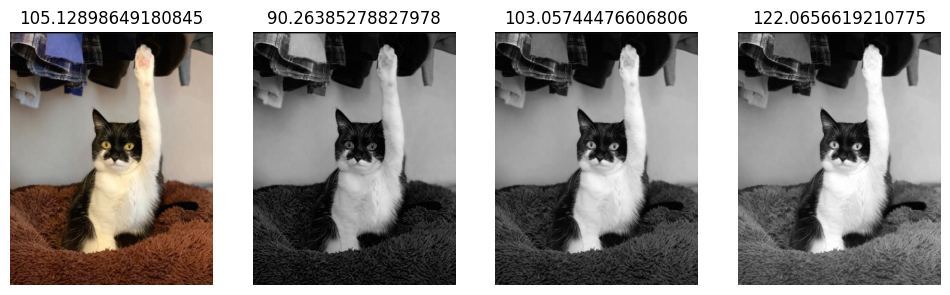

In [ ]:
# TODO: Hiển thị 4 ảnh trên cùng một hàng:
# ảnh gốc | kênh R (dùng colormap Reds) | kênh G (Greens) | kênh B (Blues)
# Thêm tiêu đề và giá trị mean vào tiêu đề mỗi kênh


fig, axes = plt.subplots(1, 4, figsize=(12,6))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].axis("off")
axes[0].set_title(mean)

axes[1].imshow(cv2.cvtColor(blue, cv2.COLOR_BGR2RGB))
axes[1].axis("off")
axes[1].set_title(mean_b)

axes[2].imshow(cv2.cvtColor(green, cv2.COLOR_BGR2RGB))
axes[2].axis("off")
axes[2].set_title(mean_g)

axes[3].imshow(cv2.cvtColor(red, cv2.COLOR_BGR2RGB))
axes[3].axis("off")
axes[3].set_title(mean_r)
plt.show()

# Câu hỏi: Kênh nào trông sáng nhất? Kênh nào tối nhất? Giải thích tại sao.
# Trả lời: Kênh sáng nhất: red. Kênh tối nhất: blue. Khi nhìn vào mean ta sẽ hiểu được rõ ràng. Mean của red là cao nhất nên sáng nhất, của blue thấp nhất nên tối nhất


---
## Bài 6 — Tự viết hàm chuyển Grayscale (2 điểm)

Đây là bài quan trọng nhất. Bạn sẽ tự cài đặt lại chức năng mà OpenCV đã có sẵn — để hiểu nó thực sự làm gì.

In [75]:
# TODO: Viết hàm `chuyen_grayscale(img)` nhận vào ảnh BGR và trả về ảnh grayscale
# Yêu cầu:
# - Tự tính theo công thức: Gray = 0.299*R + 0.587*G + 0.114*B
# - KHÔNG dùng cv2.cvtColor
# - Output phải có dtype uint8 và shape (H, W) — không phải (H, W, 1)
# - Xử lý đúng thứ tự kênh (nhớ OpenCV đọc BGR không phải RGB)

def chuyen_grayscale(img):
    """
    Chuyển ảnh màu BGR sang grayscale.
    
    Args:
        img: numpy array shape (H, W, 3), dtype uint8, thứ tự kênh BGR
    Returns:
        numpy array shape (H, W), dtype uint8
    """
    gray = np.dot(img[..., :3], [0.114, 0.587, 0.299])
    gray = gray.astype(np.uint8)

    return gray

In [81]:
# TODO: Kiểm tra hàm bạn vừa viết
# 1. Gọi hàm với ảnh gốc, lưu vào `gray_tu_viet`
# 2. Dùng cv2.cvtColor để tạo `gray_opencv` (đây là kết quả chuẩn)
# 3. Tính sai lệch tuyệt đối trung bình giữa 2 kết quả
# Nếu hàm bạn viết đúng, sai lệch sẽ rất nhỏ (thường < 1.0 do làm tròn số thực)

gray_tu_viet = chuyen_grayscale(img)
gray_opencv = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
mae = np.mean(np.abs(gray_tu_viet.astype(float) - gray_opencv.astype(float)))
print(f"MAE: {mae:.4f}")
# TODO: In ra shape và dtype của gray_tu_viet để xác nhận đúng format
print(f"Shape: {gray_tu_viet.shape}, Dtype: {gray_tu_viet.dtype}")

MAE: 0.4864
Shape: (920, 736), Dtype: uint8


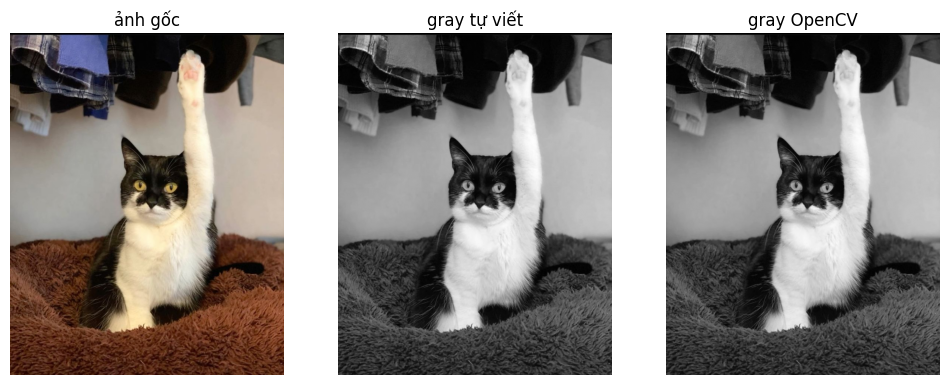

In [83]:
# TODO: Hiển thị 3 ảnh cạnh nhau để so sánh:
# ảnh màu gốc | grayscale tự viết | grayscale của OpenCV
# Thêm tiêu đề cho từng ảnh, dùng cmap='gray' cho 2 ảnh grayscale

fig, axes = plt.subplots(1, 3, figsize=(12,6))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].axis("off")
axes[0].set_title("ảnh gốc")

axes[1].imshow(gray_tu_viet, cmap = 'gray')
axes[1].axis("off")
axes[1].set_title("gray tự viết")

axes[2].imshow(gray_opencv, cmap = 'gray')
axes[2].axis("off")
axes[2].set_title("gray OpenCV")

plt.show()

(1108, 887, 3), (920, 736)


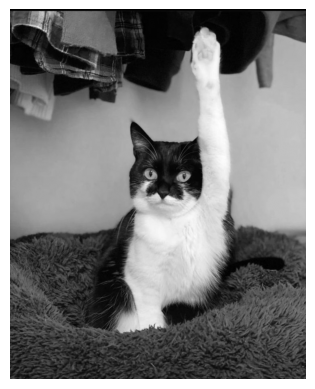

In [ ]:
# TODO: Lưu ảnh grayscale của bạn ra file tên `ket_qua_gray.jpg`
# Sau đó đọc lại file vừa lưu và kiểm tra shape có đúng không
plt.imshow(gray_tu_viet, cmap = 'gray')
plt.axis("off")
plt.savefig('ket_qua_gray.png', dpi=300, bbox_inches='tight', pad_inches=0)

new_gray = cv2.imread("ket_qua_gray.png")
print(new_gray.shape, gray_tu_viet.shape, sep=", ")
# Câu hỏi: Khi bạn lưu ảnh grayscale rồi đọc lại, shape có thể bị thay đổi không?
# Thử in ra và giải thích kết quả bạn thấy.
# Trả lời: Có thay đổi, do sử dụng plt để lưu ảnh nó sẽ thay đổi dpi (cụ thể ở đây là 300) nên sẽ bị ép độ phân giải khiến shape to hơn. Còn khi sử dụng OpenCV để lưu ảnh thì sẽ không bị thay đổi shape và Channel


---
## Câu hỏi tổng kết

Trả lời ngắn gọn bằng lời văn, không cần code.

**Câu 1:** Ảnh có shape `(480, 640, 3)` — con số nào là chiều cao, con số nào là chiều rộng? Tại sao thứ tự lại là (H, W, C) chứ không phải (W, H, C)?

- Hình ảnh có shape `(480, 640, 3)` có nghĩa là:
  - `480` là chiều cao (H)
  - `640` là chiều rộng (W)
  - `3` là số kênh màu (C)
- Thứ tự (H, W, C) được sử dụng phổ biến trong xử lý ảnh vì nó phản ánh cách mà dữ liệu được lưu trữ trong bộ nhớ và cách mà các thuật toán xử lý ảnh hoạt động. Nhiều thư viện và công cụ xử lý ảnh, bao gồm OpenCV, sử dụng định dạng này để tối ưu hóa hiệu suất và tương thích với các chuẩn công nghiệp. Nếu sử dụng (W, H, C), sẽ gây nhầm lẫn và không tương thích với các thư viện phổ biến, dẫn đến lỗi khi xử lý ảnh.

---

**Câu 2:** Nếu bạn muốn tạo một ảnh toàn màu đỏ thuần túy kích thước 200×200 pixel bằng NumPy (không đọc từ file), bạn cần gán giá trị gì cho từng kênh? Viết 1-2 dòng code minh họa.

- Để tạo một ảnh toàn màu đỏ thuần túy kích thước 200×200 pixel, bạn cần gán giá trị `255` cho kênh đỏ (R) và `0` cho các kênh xanh (G) và xanh dương (B). Dưới đây là ví dụ code minh họa:

```python
import numpy as np
red_image = np.zeros((200, 200, 3), dtype=np.uint8)
red_image[:, :, 0] = 255  # Gán giá trị 255 cho kênh đỏ (R)
```

---

**Câu 3:** Sau buổi học hôm nay, theo bạn điều gì là khó hiểu nhất? Điều gì bạn muốn tìm hiểu thêm?

Hiện tại không có điều gì khó hiểu, nhưng em muốn tìm hiểu thêm về cách các thuật toán xử lý ảnh hoạt động bên dưới lớp giao diện của OpenCV, để hiểu rõ hơn về cách chúng ta có thể tối ưu hóa và tùy chỉnh khi cần thiết.